# SR model training metrics

Compares the three super-resolution models on what their training runs recorded: reconstruction quality, epoch time and GPU memory. Every number is read from the metrics pickle each training notebook saved next to its checkpoint, so this notebook only needs `4_srcnn`, `5_edsr` and `6_esrgan` to have been run.

The cost of running the models at inference time belongs to the detection pipeline, where the three of them are applied to the same test split, and is reported there.

In [1]:
import os
import pickle
import sys

sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "..")))

from srlib.constants import DL_RESULTS_DIR, EDSR_SCALE_FACTOR, ESRGAN_SCALE_FACTOR
from srlib.model_registry import model_artifacts, print_available_runs
from srlib.deep_learning.visualization import (
    plot_sr_memory,
    plot_sr_metrics,
    plot_sr_time,
)

## Resolve the training runs

In [2]:
# Leave a run as None to take the most recent one, or pin a timestamp to
# report an older run.
SRCNN_RUN = None
EDSR_RUN = None
ESRGAN_RUN = None

print_available_runs()

srcnn_artifacts = model_artifacts("SRCNN", SRCNN_RUN)
edsr_artifacts = model_artifacts("EDSR", EDSR_RUN, scale_factor=EDSR_SCALE_FACTOR)
esrgan_artifacts = model_artifacts("ESRGAN", ESRGAN_RUN, scale_factor=ESRGAN_SCALE_FACTOR)

print(
    "\nReporting runs -> "
    f"SRCNN: {srcnn_artifacts['timestamp']}, "
    f"EDSR: {edsr_artifacts['timestamp']}, "
    f"ESRGAN: {esrgan_artifacts['timestamp']}"
)

SRCNN: 1 run(s)
  - 20260916_112639 (latest)
EDSR: 1 run(s)
  - 20260916_190338 (latest)
ESRGAN: 1 run(s)
  - 20260915_175433 (latest)
VGG16: 1 run(s)
  - 20260916_000014 (latest)

Reporting runs -> SRCNN: 20260916_112639, EDSR: 20260916_190338, ESRGAN: 20260915_175433


In [3]:
with open(srcnn_artifacts["metrics"], "rb") as f:
    srcnn_train_metrics = pickle.load(f)
with open(edsr_artifacts["metrics"], "rb") as f:
    edsr_train_metrics = pickle.load(f)
with open(esrgan_artifacts["metrics"], "rb") as f:
    esrgan_train_metrics = pickle.load(f)

print(f"Loaded metrics for {len(srcnn_train_metrics)} SRCNN keys, "
      f"{len(edsr_train_metrics)} EDSR keys, "
      f"{len(esrgan_train_metrics)} ESRGAN keys")

Loaded metrics for 13 SRCNN keys, 13 EDSR keys, 13 ESRGAN keys


## Reconstruction quality

Loss, PSNR and SSIM on train, validation and test. The three models report the mean over the last epoch, so the rows are comparable.

(<Figure size 1000x1000 with 6 Axes>,
 array([[<Axes: title={'center': 'Train PSNR'}, ylabel='dB'>,
         <Axes: title={'center': 'Train SSIM'}>],
        [<Axes: title={'center': 'Val PSNR'}, ylabel='dB'>,
         <Axes: title={'center': 'Val SSIM'}>],
        [<Axes: title={'center': 'Eval PSNR'}, ylabel='dB'>,
         <Axes: title={'center': 'Eval SSIM'}>]], dtype=object))

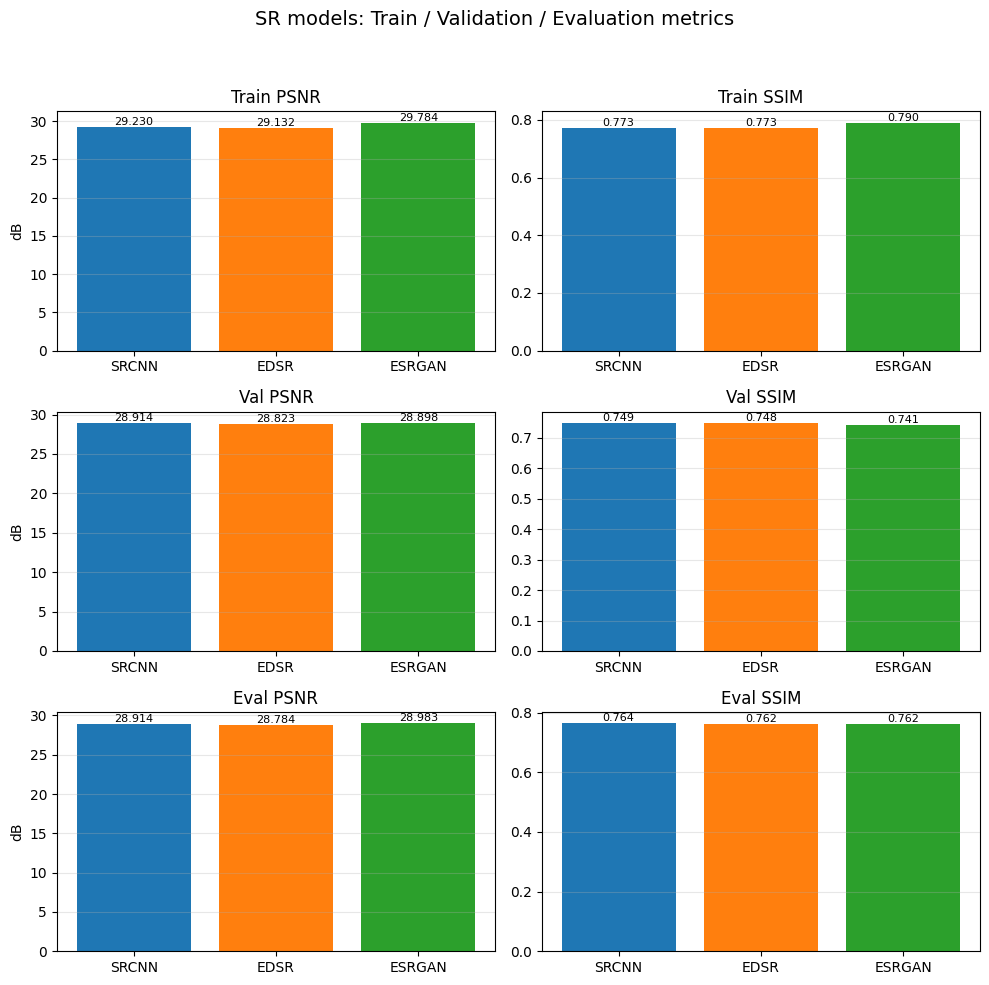

In [4]:
plot_sr_metrics(
    srcnn_train_metrics,
    edsr_train_metrics,
    esrgan_train_metrics,
    save_path=DL_RESULTS_DIR,
)

## Training time

(<Figure size 1200x400 with 2 Axes>,
 array([<Axes: title={'center': 'Training (mean per epoch)'}, ylabel='Seconds'>,
        <Axes: title={'center': 'Evaluation (test set)'}, ylabel='Seconds'>],
       dtype=object))

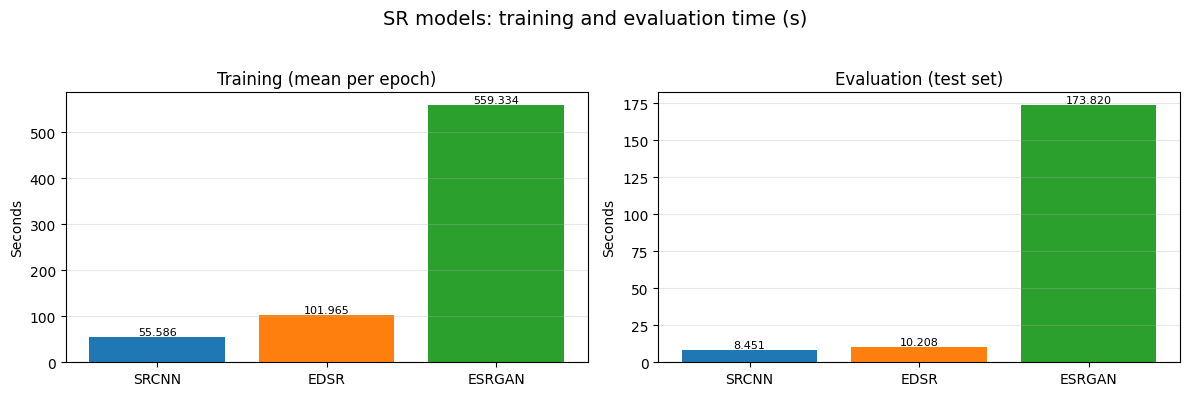

In [5]:
plot_sr_time(
    srcnn_train_metrics,
    edsr_train_metrics,
    esrgan_train_metrics,
    save_path=DL_RESULTS_DIR,
)

## Training GPU memory

(<Figure size 1400x800 with 4 Axes>,
 array([[<Axes: title={'center': 'Training (mean)'}, ylabel='MB'>,
         <Axes: title={'center': 'Training (peak)'}, ylabel='MB'>],
        [<Axes: title={'center': 'Evaluation (mean)'}, ylabel='MB'>,
         <Axes: title={'center': 'Evaluation (peak)'}, ylabel='MB'>]],
       dtype=object))

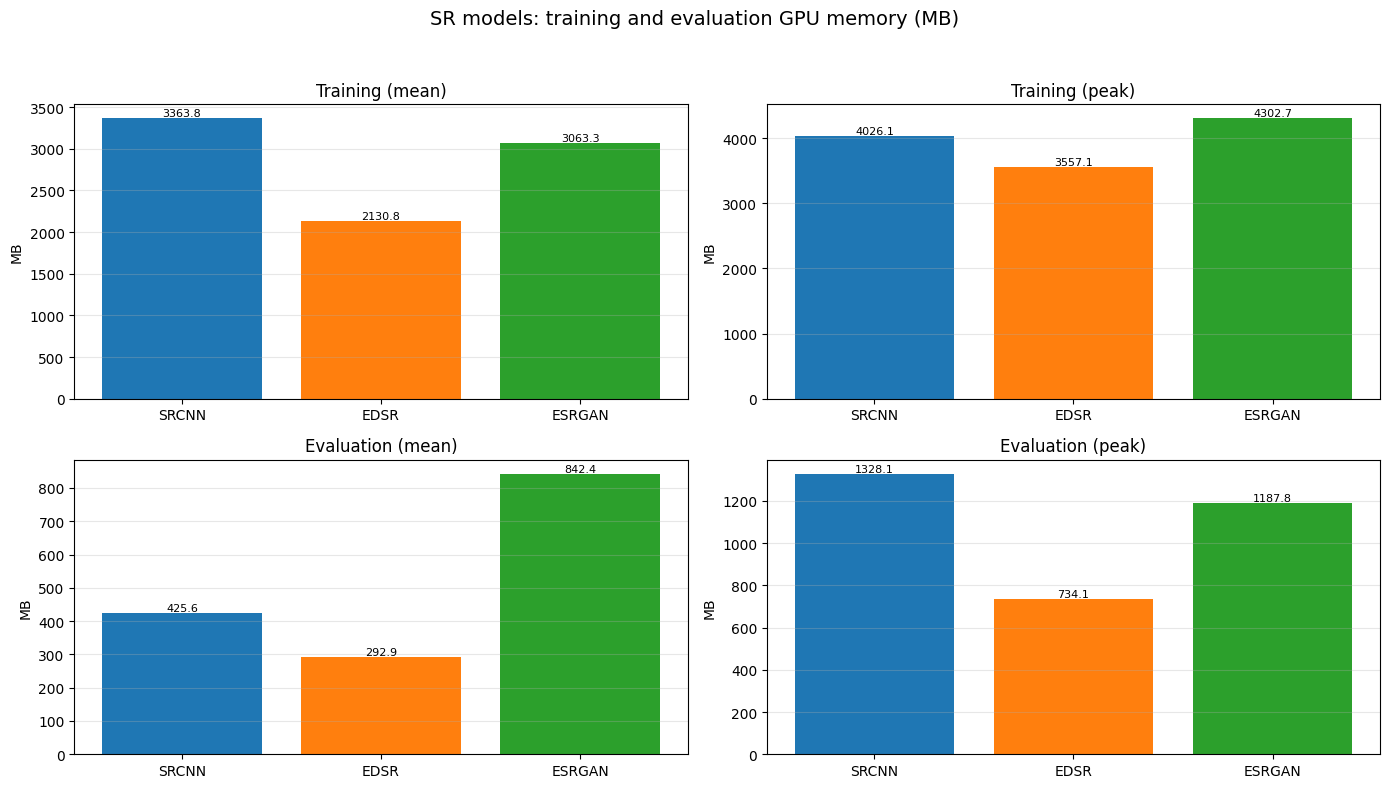

In [6]:
plot_sr_memory(
    srcnn_train_metrics,
    edsr_train_metrics,
    esrgan_train_metrics,
    save_path=DL_RESULTS_DIR,
)